In [45]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import h5py
import anndata as ad

seed = 123

In [47]:
data_dir = '../data/frangieh'
adata = sc.read_h5ad(f'{data_dir}/rna.h5ad')

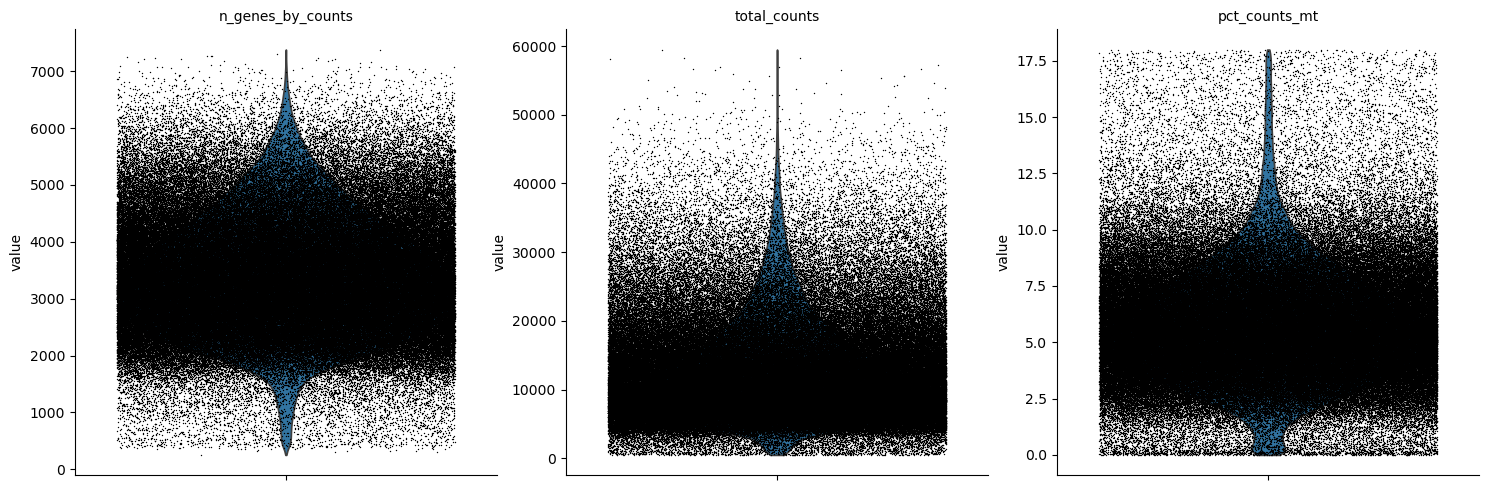

In [3]:
# mitochondrial genes, 'MT-' for human, 'Mt-' for mouse
adata.var['mt'] = adata.var_names.str.startswith('MT-')
# ribosomal genes
adata.var['ribo'] = adata.var_names.str.startswith(('RPS', 'RPL'))
# hemoglobin genes
adata.var['hb'] = adata.var_names.str.contains('^HB[^(P)]')

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo', 'hb'], inplace=True, log1p=True)

sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
)

There is a relatively high percentage of mitochondrial genes in a lot of cells. However, for most cells, it's below 10% and for some even very close to 0.0%. Totsl counts and n_genes_by_counts looks good. Total counts could be filtered a bit more stringently with a threshold of around 50000, but 60000 also looks okay.

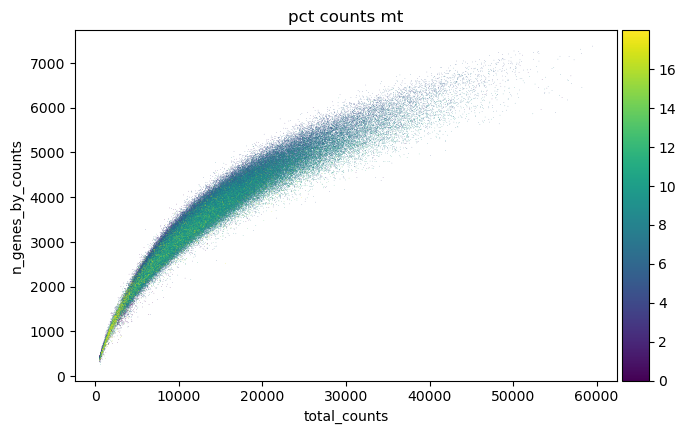

In [4]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')

Scatter plot looks good. There are some cells with a high mt percentage paired with low number of genes and low number of total counts.<br>Overall, preprocessing of the data looks good, so now further processing will be done for now.

In [5]:
# Saving count data
# adata.layers['doublets'] = adata.X.copy()

# Scrublet doublet detection (might also use scdblfinder in R later)
# sc.pp.scrublet(adata)
# adata.obs['doublet'] = ['doublet' if element else 'singlet' for element in adata.obs.predicted_doublet.tolist()]
# adata = adata[adata.obs.doublet=='singlet']

**Scublet dosen't run in the VM, so we will assume that all doublets have been removed already, which is very likely**

<Axes: xlabel='data', ylabel='Count'>

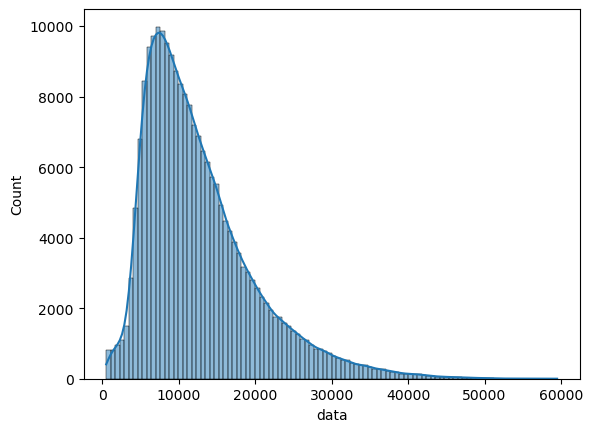

In [6]:
# Saving count data
adata.layers['counts'] = adata.X.copy()

df_plot = pd.DataFrame(columns=['data'])
df_plot['data'] = adata.layers['counts'].sum(1).flatten().tolist()[0]

sns.histplot(data=df_plot, x='data', bins=100, kde=True)

<Axes: xlabel='data', ylabel='Count'>

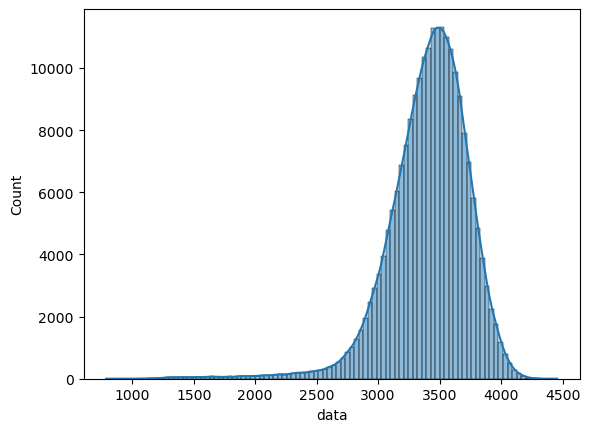

In [7]:
# normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

df_plot = pd.DataFrame(columns=['data'])
df_plot['data'] = adata.X.sum(1).flatten().tolist()[0]

sns.histplot(data=df_plot, x='data', bins=100, kde=True)

Looks a little weird because it's shifted to the right. Therefore, there are some genes with very little counts in cells. This could be a sign for more filtering that is necessary.

In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000)

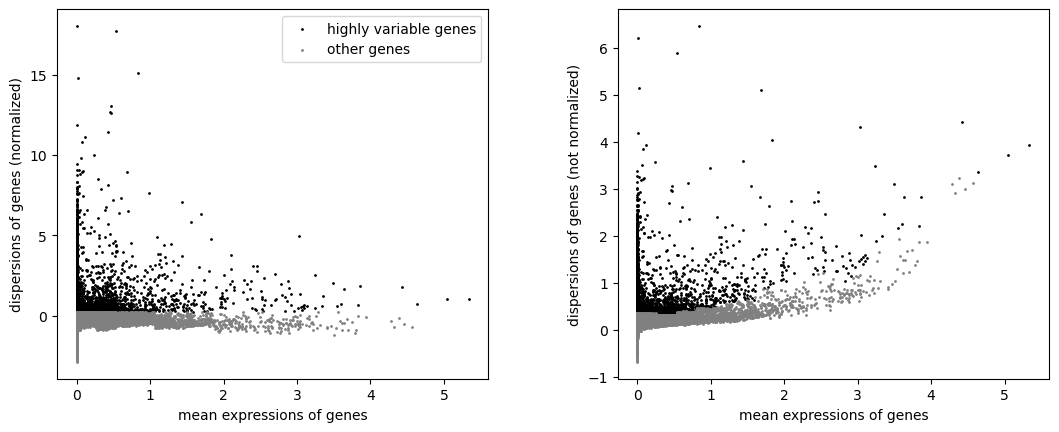

In [9]:
sc.pl.highly_variable_genes(adata)

In [10]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

# Save data
adata.write(f"{data_dir}/dataset_pp_tim.h5ad")

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
data_dir = '../data/frangieh'
adata = sc.read_h5ad(f"{data_dir}/dataset_pp_tim.h5ad")

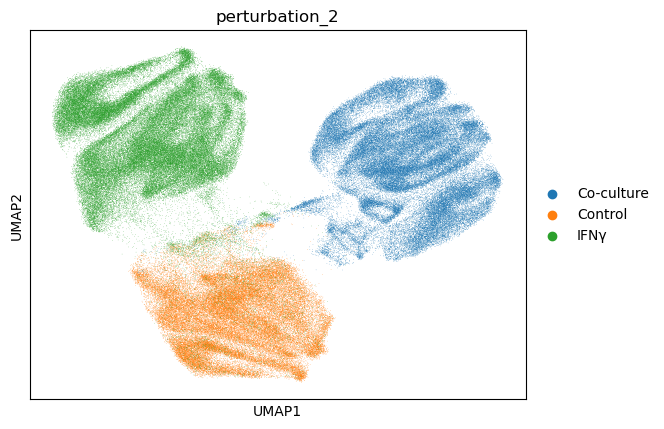

In [12]:
sc.pl.umap(adata, color=['perturbation_2'])

Cells cluster very well by treatment condition.<br>
For classification, a gradient boosted tree method will be used using the xgboost package. Model quality will be evaluated using an f1-score.<br><br>
**Categories are defined as follows:**<br>
<ul>
  <li>0: Control</li>
  <li>1: IFN gamma</li>
  <li>2: Co-culture</li>
</ul>

In [41]:
mapping = {
    'Control':0,
    'IFNγ':1,
    'Co-culture':2
}

adata.obs['condition_class'] = adata.obs.perturbation_2.map(mapping)

In [47]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

def fit_xgb(data, test_size, n_estimators, max_depth):

    X_train, X_test, y_train, y_test = train_test_split(data[:,data.var['highly_variable']==True].X, data.obs.condition_class, test_size=test_size,
                                                        stratify=data.obs.condition_class, random_state=seed)

    # create model instance
    bst = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=0.5, objective='multi:softprob')
    # fit model
    bst.fit(X_train, y_train)
    # make predictions
    preds = bst.predict(X_test)

    score = round(
        f1_score(
            y_test, 
            preds, 
            average="weighted" # as frequencies are not the same in all classes, this will weight accordingly to the frequenc y of the class))
            # average=None
        ), 
        3
    )
    return(bst, score)

score_list = []
run=1
for n_estimators in range(4,7):
    for max_depth in range(4,7):
        print(f'Commencing run {run}')
        _, f1 = fit_xgb(adata, .2, n_estimators, max_depth)
        res={
            'run':run,
            'n_estimators':n_estimators,
            'max_depth':max_depth,
            'f1':f1
        }
        score_list.append(res)
        print(f'Run {run} completed. Score: {f1}')
        run+=1

scores = pd.DataFrame(score_list)
print(scores)

Commencing run 1
Run 1 completed. Score: 0.979
Commencing run 2
Run 2 completed. Score: 0.981
Commencing run 3
Run 3 completed. Score: 0.982
Commencing run 4
Run 4 completed. Score: 0.98
Commencing run 5
Run 5 completed. Score: 0.982
Commencing run 6
Run 6 completed. Score: 0.983
Commencing run 7
Run 7 completed. Score: 0.982
Commencing run 8
Run 8 completed. Score: 0.983
Commencing run 9
Run 9 completed. Score: 0.984
   run  n_estimators  max_depth     f1
0    1             4          4  0.979
1    2             4          5  0.981
2    3             4          6  0.982
3    4             5          4  0.980
4    5             5          5  0.982
5    6             5          6  0.983
6    7             6          4  0.982
7    8             6          5  0.983
8    9             6          6  0.984


**Optimal parameters seem to be:**<br>
max_depth = 5 -> no big improvements thereafter<br>
n_estimators = 4 -> no big improvements thereafter<br><br>
These hyperparameters should not be set to high as otherwise the model might overfit

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/xgboost/data.py:400: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/xgboost/data.py:400: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")


<Axes: >

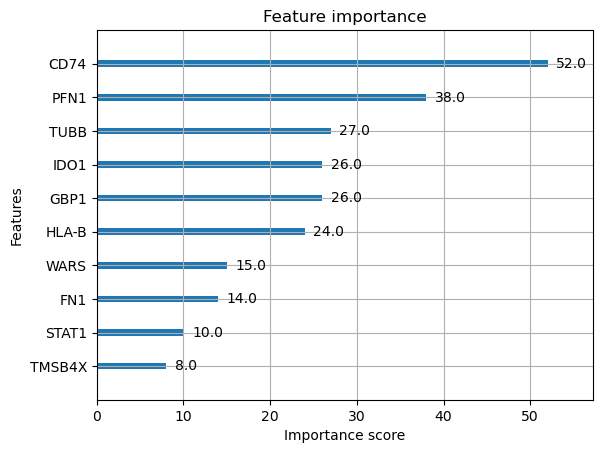

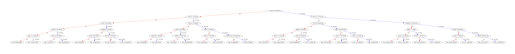

In [49]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# evaluate feature importance

def fit_xgb(data, test_size, n_estimators, max_depth):
    X_train, X_test, y_train, y_test = train_test_split(data[:,data.var['highly_variable']==True].X, data.obs.condition_class, test_size=test_size,
                                                        stratify=data.obs.condition_class, random_state=seed)

    X_train = pd.DataFrame.sparse.from_spmatrix(X_train, columns=data[:,data.var['highly_variable']==True].var_names)
    X_test = pd.DataFrame.sparse.from_spmatrix(X_test, columns=data[:,data.var['highly_variable']==True].var_names)
    
    # create model instance
    bst = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=0.5, objective='multi:softprob', importance_type='weight')
    # fit model
    bst.fit(X_train, y_train)
    # make predictions
    preds = bst.predict(X_test)

    score = round(
        f1_score(
            y_test, 
            preds, 
            average="weighted" # as frequencies are not the same in all classes, this will weight accordingly to the frequenc y of the class))
            # average=None
        ), 
        3
    )
    return(bst, score)
    
bst, f1 = fit_xgb(adata, .2, 4, 5)
xgb.plot_importance(bst, max_num_features=10)
xgb.plot_tree(bst)

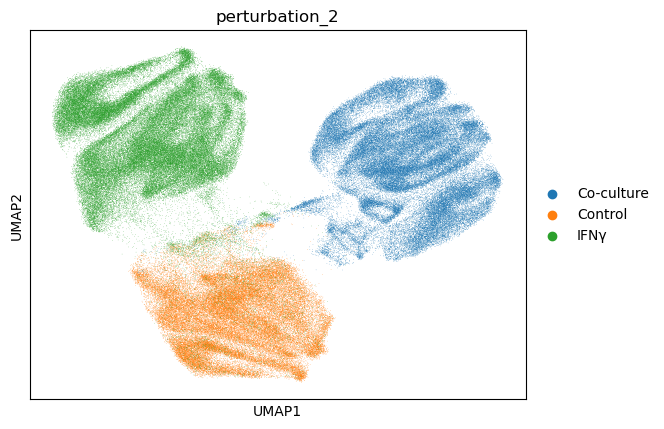

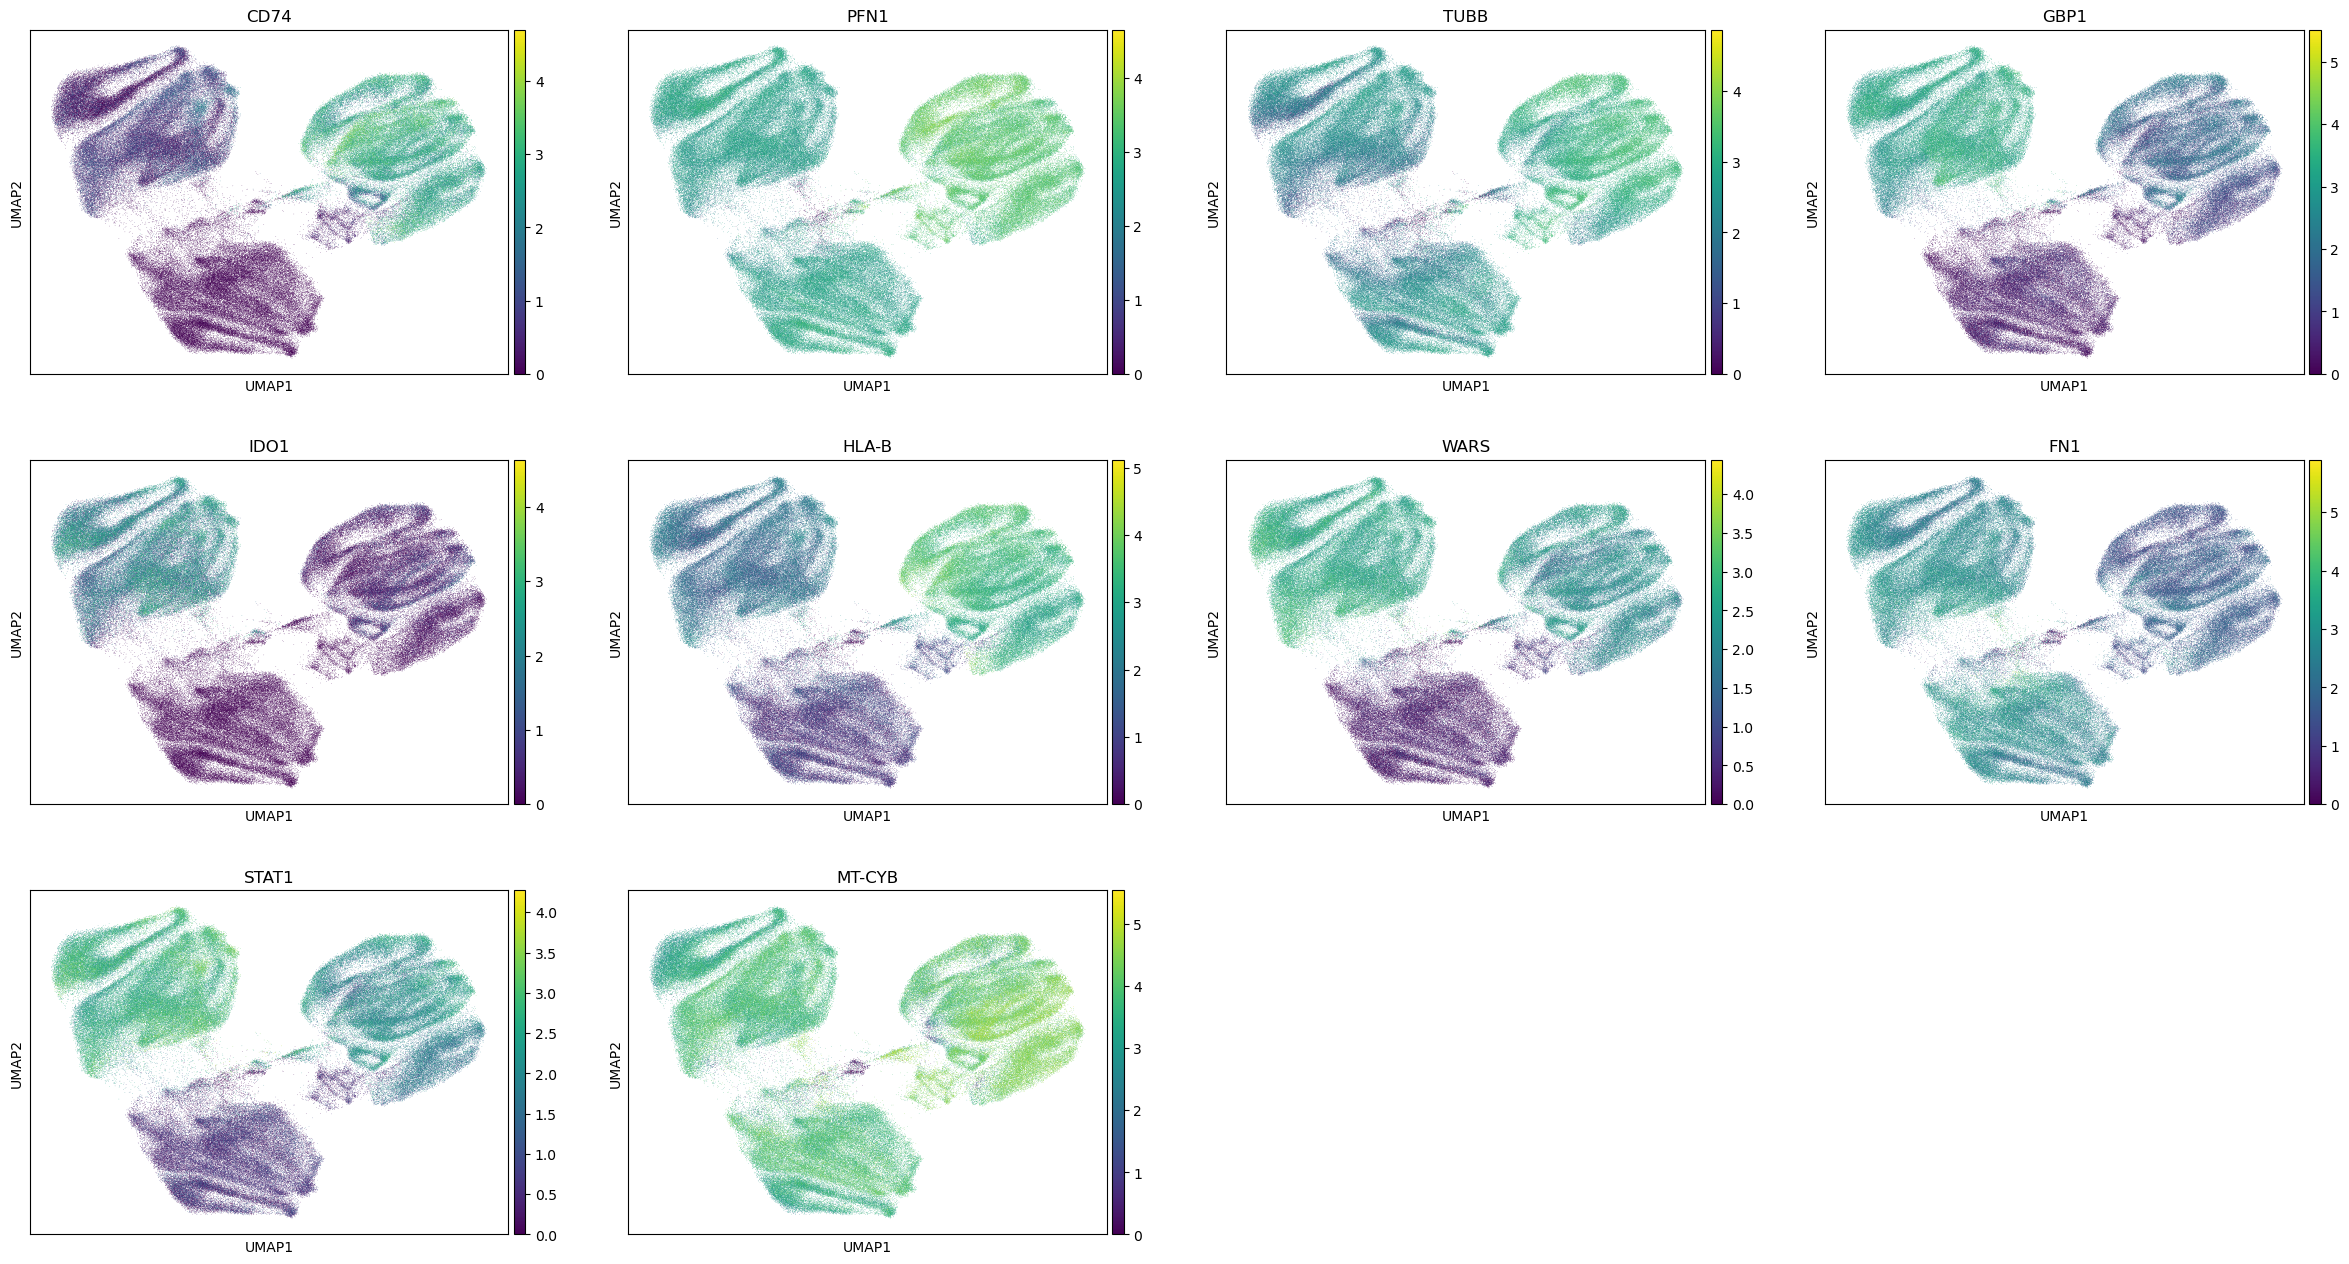

In [50]:
importances = pd.DataFrame(bst.feature_importances_, bst.feature_names_in_, columns=['importance'])

top_10_features = importances.sort_values('importance', ascending=False)[0:10].index
#for feature in top_10_features:
 #   _vals = adata[:,adata.var_names==feature].X
  #  _vals = _vals.toarray().flatten()
   # adata.obs[feature] = _vals>_vals.mean()

sc.pl.umap(adata, color=['perturbation_2'])
sc.pl.umap(adata, color=top_10_features.values.tolist())

The top 10 most important features show clear separation by cluster linked to the different treatment conditions. Based on the UMAPs, co-culture condition seems to be the condition with the most differences to the other conditions which are a little more similar. However, the UMAP shows that the model captures differences between treatment conditions rather well.